## This is the code to generate the lift for class imbalance experiment

By default, if you play this file directly, it will generate the Lift plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Compute the percentage of minority group appears in top-k -> Compute the Lift for each K and ratio -> Plot the Lift

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Lift Plot 

You don't need to change anything else if you only want to produce the Lift plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [10]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

# Read-In Area

Change the following filename if you want to test on other estimation results.

In [11]:
IF_9_1 = pd.read_csv("ClassImbalance/IF_9_1_class.csv")
IF_8_2 = pd.read_csv("ClassImbalance/IF_8_2_class.csv")
IF_7_3 = pd.read_csv("ClassImbalance/IF_7_3_class.csv")
IF_6_4 = pd.read_csv("ClassImbalance/IF_6_4_class.csv")
IF_5_5 = pd.read_csv("ClassImbalance/IF_5_5_class.csv")


TC_9_1 = pd.read_csv("ClassImbalance/TC_9_1_class.csv")
TC_8_2 = pd.read_csv("ClassImbalance/TC_8_2_class.csv")
TC_7_3 = pd.read_csv("ClassImbalance/TC_7_3_class.csv")
TC_6_4 = pd.read_csv("ClassImbalance/TC_6_4_class.csv")
TC_5_5 = pd.read_csv("ClassImbalance/TC_5_5_class.csv")

Label_1 = pd.read_csv("ClassImbalance/9_1_class_labelIDs.csv")
Label_2 = pd.read_csv("ClassImbalance/8_2_class_labelIDs.csv")
Label_3 = pd.read_csv("ClassImbalance/7_3_class_labelIDs.csv")
Label_4 = pd.read_csv("ClassImbalance/6_4_class_labelIDs.csv")
Label_5 = pd.read_csv("ClassImbalance/5_5_class_labelIDs.csv")


# Analyze Area

1. We store all the information we need in lists here.

In [12]:
sorted_IF_lists = [IF_9_1, IF_8_2,IF_7_3,IF_6_4,IF_5_5]
sorted_TC_lists = [TC_9_1, TC_8_2,TC_7_3,TC_6_4,TC_5_5]
ratio=[(9,1),(8,2),(7,3),(6,4),(5,5)]
sorted_label_lists = [Label_1,Label_2,Label_3,Label_4,Label_5]
num_lists = len(sorted_IF_lists)
random_selection_rate = [0.0785, 0.1875, 0.2932, 0.4027, 0.5020]

2. Since we always have label 1 as the minority group, here we check how many 1 appears in top-k. Then, we compute the lift based on that with the random_selection_rate.

In [13]:
for i in range(num_lists):
    ranked = (sorted_IF_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])  # your precomputed random % for this ratio/run

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]

    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    topk_tbl = pd.DataFrame({
        "k": Ks,
        "%1s_topk": topk_rates,
    })

    topk_tbl["lift@k"] = topk_tbl["%1s_topk"] / p_random

    topk_tbl["gain@k"] = topk_tbl["%1s_topk"] - p_random

    print(f"Run {i+1}  Ratio: {ratio[i]}  (random p={p_random:.4f})  top-k results:")
    print(topk_tbl)

Run 1  Ratio: (9, 1)  (random p=0.0785)  top-k results:
      k  %1s_topk     lift@k    gain@k
0    10  1.000000  12.738854  0.921500
1    20  1.000000  12.738854  0.921500
2    50  1.000000  12.738854  0.921500
3   100  1.000000  12.738854  0.921500
4   200  1.000000  12.738854  0.921500
5   400  0.982500  12.515924  0.904000
6   800  0.601250   7.659236  0.522750
7  1600  0.312500   3.980892  0.234000
8  3200  0.161875   2.062102  0.083375
Run 2  Ratio: (8, 2)  (random p=0.1875)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  5.333333  0.812500
1    20  1.000000  5.333333  0.812500
2    50  1.000000  5.333333  0.812500
3   100  1.000000  5.333333  0.812500
4   200  1.000000  5.333333  0.812500
5   400  1.000000  5.333333  0.812500
6   800  0.973750  5.193333  0.786250
7  1600  0.653750  3.486667  0.466250
8  3200  0.354687  1.891667  0.167187
Run 3  Ratio: (7, 3)  (random p=0.2932)  top-k results:
      k  %1s_topk    lift@k    gain@k
0    10  1.000000  3.410

3. Then, we group the lift based on the ratio and k for furthering ploting the graph.

In [14]:
records = [] 

for i in range(num_lists):
    ranked = (sorted_IF_lists[i]
              .merge(sorted_label_lists[i], left_on="Train_ID", right_on="id", how="left"))
    ranked = ranked.drop(columns=["id"])

    p_random = float(random_selection_rate[i])   

    Ks = [k for k in [10, 20, 50, 100, 200, 400, 800, 1600, 3200] if 1 <= k <= len(ranked)]
    topk_rates = [ranked["label"].head(k).mean() for k in Ks]
    lifts = [(r / p_random) if p_random > 0 else np.nan for r in topk_rates]

    for k, lift in zip(Ks, lifts):
        records.append({"ratio": ratio[i], "k": k, "lift": lift})

all_tbl = pd.DataFrame(records)

In [15]:
print(all_tbl)

     ratio     k       lift
0   (9, 1)    10  12.738854
1   (9, 1)    20  12.738854
2   (9, 1)    50  12.738854
3   (9, 1)   100  12.738854
4   (9, 1)   200  12.738854
5   (9, 1)   400  12.515924
6   (9, 1)   800   7.659236
7   (9, 1)  1600   3.980892
8   (9, 1)  3200   2.062102
9   (8, 2)    10   5.333333
10  (8, 2)    20   5.333333
11  (8, 2)    50   5.333333
12  (8, 2)   100   5.333333
13  (8, 2)   200   5.333333
14  (8, 2)   400   5.333333
15  (8, 2)   800   5.193333
16  (8, 2)  1600   3.486667
17  (8, 2)  3200   1.891667
18  (7, 3)    10   3.410641
19  (7, 3)    20   3.410641
20  (7, 3)    50   3.410641
21  (7, 3)   100   3.410641
22  (7, 3)   200   3.410641
23  (7, 3)   400   3.402115
24  (7, 3)   800   3.389325
25  (7, 3)  1600   2.896913
26  (7, 3)  3200   1.803377
27  (6, 4)    10   2.483238
28  (6, 4)    20   2.483238
29  (6, 4)    50   2.483238
30  (6, 4)   100   2.433573
31  (6, 4)   200   2.445990
32  (6, 4)   400   2.427365
33  (6, 4)   800   2.272163
34  (6, 4)  1600   1

Then, we shall obtain for each ratio and each k, what is the lift of that.

In [16]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
all_tbl["ratio"] = pd.Categorical(all_tbl["ratio"], categories=ratio, ordered=True)

pivot_kx = all_tbl.pivot_table(index="k", columns="ratio", values="lift", aggfunc="mean")
pivot_rx = all_tbl.pivot_table(index="ratio", columns="k", values="lift", aggfunc="mean")
print(pivot_kx)

ratio     (9, 1)    (8, 2)    (7, 3)    (6, 4)    (5, 5)
k                                                       
10     12.738854  5.333333  3.410641  2.483238  1.792829
20     12.738854  5.333333  3.410641  2.483238  1.593625
50     12.738854  5.333333  3.410641  2.483238  1.155378
100    12.738854  5.333333  3.410641  2.433573  0.956175
200    12.738854  5.333333  3.410641  2.445990  0.896414
400    12.515924  5.333333  3.402115  2.427365  1.070717
800     7.659236  5.193333  3.389325  2.272163  1.352092
1600    3.980892  3.486667  2.896913  1.958654  1.410608
3200    2.062102  1.891667  1.803377  1.414670  1.289841


# Plot Area

Plot 1: x axis is k, bars are ratio

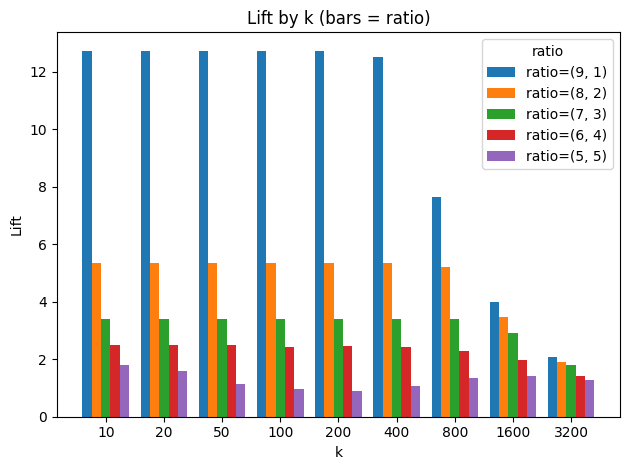

In [17]:
fig, ax = plt.subplots()
x = np.arange(len(pivot_kx.index))
n_groups = len(pivot_kx.columns)
bar_width = 0.8 / max(n_groups, 1)

for j, col in enumerate(pivot_kx.columns):
    ax.bar(x + j*bar_width - 0.4 + bar_width/2, pivot_kx[col].values, width=bar_width, label=f"ratio={col}")

ax.set_xlabel("k")
ax.set_ylabel("Lift")
ax.set_title("Lift by k (bars = ratio)")
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in pivot_kx.index])
ax.legend(title="ratio")
plt.tight_layout()
plt.show()

Plot 2: x axis is ratio, bars are k

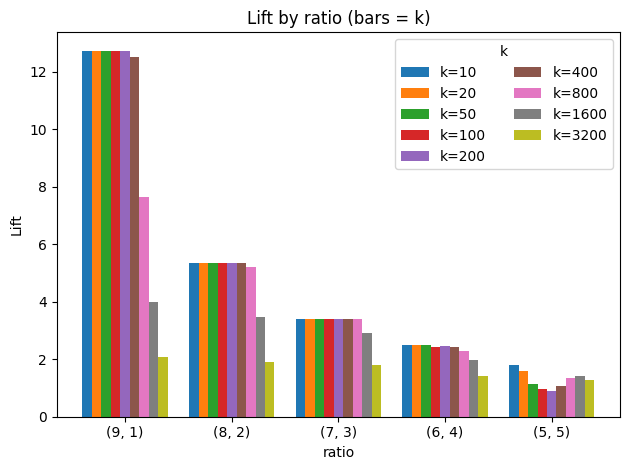

In [18]:
fig, ax = plt.subplots()
x = np.arange(len(pivot_rx.index))
n_groups = len(pivot_rx.columns)
bar_width = 0.8 / max(n_groups, 1)

for j, col in enumerate(pivot_rx.columns):
    ax.bar(x + j*bar_width - 0.4 + bar_width/2, pivot_rx[col].values, width=bar_width, label=f"k={col}")

ax.set_xlabel("ratio")
ax.set_ylabel("Lift")
ax.set_title("Lift by ratio (bars = k)")
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in pivot_rx.index])
ax.legend(title="k", ncol=2)
plt.tight_layout()
plt.show()